# RFM-сегментация.

Кто наши лучшие клиенты?
Кто уходит и его можно вернуть?
Кто потерян навсегда?
На кого тратить маркетинговый бюджет?

# Мастер-таблица:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

master = pd.read_csv(
    '../data/processed_data/master_orders.csv',
    parse_dates=['order_purchase_timestamp']
)

print("Загружено:")
print(f"  Заказов: {len(master):,}")
print(f"  Клиентов: {master['customer_unique_id'].nunique():,}")

# Определим «сегодня» — день после последнего заказа в данных
snapshot_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"  Snapshot date (условное «сегодня»): {snapshot_date.date()}")

Загружено:
  Заказов: 96,470
  Клиентов: 93,350
  Snapshot date (условное «сегодня»): 2018-08-30


# RFM для каждого клиента

In [2]:
rfm = master.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

print("RFM посчитан для", len(rfm), "клиентов")
print()
print("Статистика:")
print(rfm[['recency', 'frequency', 'monetary']].describe())

RFM посчитан для 93350 клиентов

Статистика:
            recency     frequency      monetary
count  93350.000000  93350.000000  93350.000000
mean     237.950070      1.033423    165.196388
std      152.589932      0.209106    226.322448
min        1.000000      1.000000      0.000000
25%      114.000000      1.000000     63.050000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.547500
max      714.000000     15.000000  13664.080000


# RFM-скоры
Разбиваем каждую метрику на 5 групп. Чем меньше дней, тем выше скор.
# Позже пояснить

In [3]:
# Recency: чем меньше — тем лучше. Обратный порядок.
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: проблема — почти все = 1. Используем rank-based подход.
# Если qcut не работает из-за дублей — используем ручную разбивку.
try:
    rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
except ValueError:
    # Fallback: если не получается — ручная логика
    rfm['F'] = pd.cut(rfm['frequency'], 
                       bins=[0, 1, 2, 3, 4, 100], 
                       labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: чем больше — тем лучше
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

print("Распределение скоров:")
print()
print("R:")
print(rfm['R'].value_counts().sort_index())
print()
print("F:")
print(rfm['F'].value_counts().sort_index())
print()
print("M:")
print(rfm['M'].value_counts().sort_index())

Распределение скоров:

R:
R
1    18638
2    18576
3    18709
4    18705
5    18722
Name: count, dtype: int64

F:
F
1    18670
2    18670
3    18670
4    18670
5    18670
Name: count, dtype: int64

M:
M
1    18673
2    18683
3    18657
4    18670
5    18667
Name: count, dtype: int64


# RFM-сегменты (почему не в процентах)

In [4]:
# Строка RFM (например, "555")
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# Функция присвоения сегмента
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    
    # Champions: лучшие по всем метрикам
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    # Loyal: хорошие по R и M, средние по F
    elif r >= 3 and m >= 3:
        return 'Loyal'
    # Potential: недавние, но мало покупали
    elif r >= 4 and f <= 2:
        return 'Potential'
    # At Risk: были хорошими, но давно не покупали
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    # Hibernating: давно, мало
    elif r <= 2 and m <= 2:
        return 'Hibernating'
    # Lost: самые плохие
    elif r == 1 and f == 1 and m == 1:
        return 'Lost'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print("Распределение по сегментам:")
seg_counts = rfm['segment'].value_counts()
print(seg_counts)
print()
print("Доли:")
print((seg_counts / len(rfm) * 100).round(2))

Распределение по сегментам:
segment
Loyal          27668
Others         24775
Hibernating    15380
At Risk        13164
Champions       6492
Potential       5871
Name: count, dtype: int64

Доли:
segment
Loyal          29.64
Others         26.54
Hibernating    16.48
At Risk        14.10
Champions       6.95
Potential       6.29
Name: count, dtype: float64


# метрики по сегментам

In [5]:
segment_summary = rfm.groupby('segment').agg(
    clients=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

segment_summary['revenue_share_%'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print("Метрики по сегментам:")
print(segment_summary)

Метрики по сегментам:
             clients  avg_recency  avg_frequency  avg_monetary  total_revenue  \
segment                                                                         
Loyal          27668       143.33           1.03        218.32     6040454.81   
At Risk        13164       393.50           1.07        243.53     3205790.21   
Others         24775       235.87           1.00        119.79     2967857.01   
Champions       6492        91.12           1.18        312.15     2026452.22   
Hibernating    15380       396.54           1.01         55.81      858368.05   
Potential       5871        90.81           1.00         54.87      322160.55   

             revenue_share_%  
segment                       
Loyal                  39.17  
At Risk                20.79  
Others                 19.25  
Champions              13.14  
Hibernating             5.57  
Potential               2.09  


# клиенты vs выручка

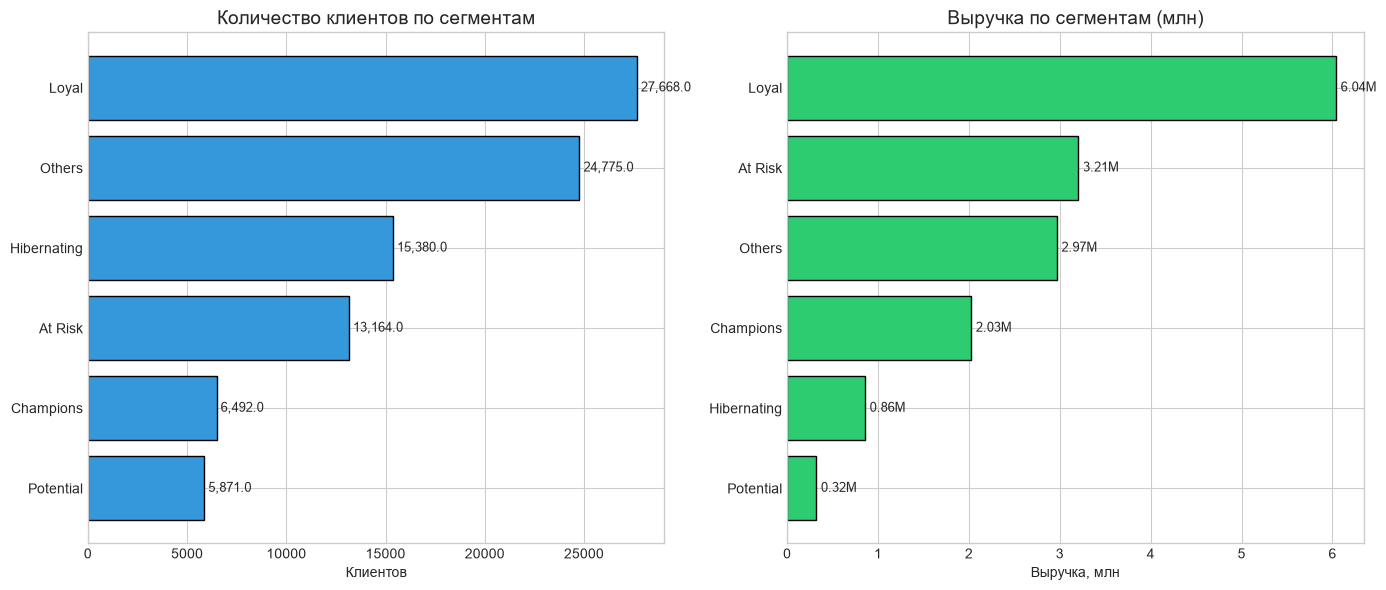

Сохранено: rfm_segments.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Клиенты
seg_sorted = segment_summary.sort_values('clients', ascending=True)
axes[0].barh(seg_sorted.index, seg_sorted['clients'], color='#3498db', edgecolor='black')
axes[0].set_title('Количество клиентов по сегментам', fontsize=14)
axes[0].set_xlabel('Клиентов')

for i, (idx, row) in enumerate(seg_sorted.iterrows()):
    axes[0].text(row['clients'] + 200, i, f"{row['clients']:,}", va='center', fontsize=9)

# Выручка
seg_sorted_rev = segment_summary.sort_values('total_revenue', ascending=True)
axes[1].barh(seg_sorted_rev.index, seg_sorted_rev['total_revenue'] / 1e6, 
             color='#2ecc71', edgecolor='black')
axes[1].set_title('Выручка по сегментам (млн)', fontsize=14)
axes[1].set_xlabel('Выручка, млн')

for i, (idx, row) in enumerate(seg_sorted_rev.iterrows()):
    axes[1].text(row['total_revenue']/1e6 + 0.05, i, 
                 f"{row['total_revenue']/1e6:.2f}M", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed_data/rfm_segments.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: rfm_segments.png")

Hibernating — много клиентов, мало выручки. Champions — мало клиентов, но высокая выручка на каждого.

# Scatter plot: Recency vs Monetary

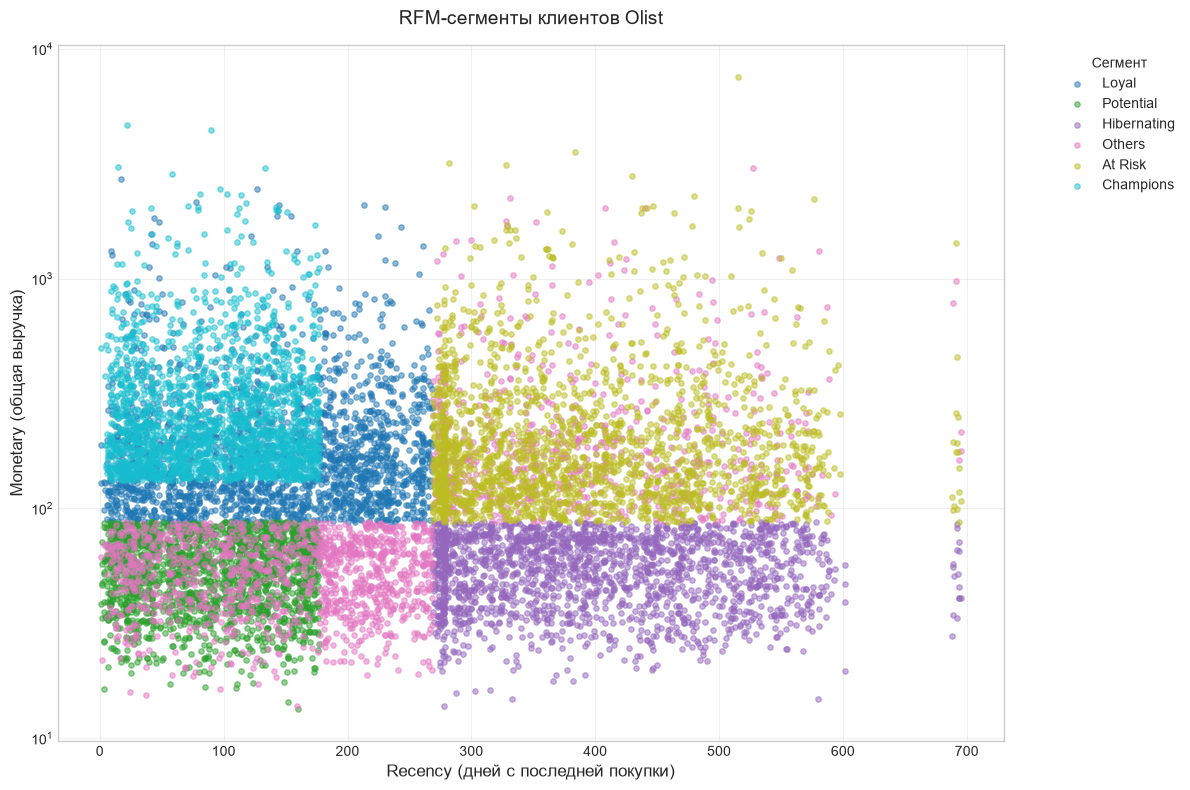

Сохранено: rfm_scatter.png


In [7]:
plt.figure(figsize=(12, 8))

# Цвета по сегментам
segments = rfm['segment'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))
color_map = dict(zip(segments, colors))

for seg in segments:
    data = rfm[rfm['segment'] == seg]
    # Сэмплируем для скорости (если много точек)
    if len(data) > 2000:
        data = data.sample(2000, random_state=42)
    plt.scatter(data['recency'], data['monetary'], 
                c=[color_map[seg]], label=seg, alpha=0.5, s=15)

plt.xlabel('Recency (дней с последней покупки)', fontsize=12)
plt.ylabel('Monetary (общая выручка)', fontsize=12)
plt.title('RFM-сегменты клиентов Olist', fontsize=14, pad=15)
plt.legend(title='Сегмент', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')  # логарифмическая шкала — из-за «китов»
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed_data/rfm_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

print("Сохранено: rfm_scatter.png")

# «At Risk» — кого можно спасти

In [8]:
at_risk = rfm[rfm['segment'] == 'At Risk']

print("Сегмент 'At Risk':")
print(f"  Клиентов: {len(at_risk):,}")
print(f"  Общая выручка (историческая): {at_risk['monetary'].sum():,.2f}")
print(f"  Средний чек: {at_risk['monetary'].mean():,.2f}")
print(f"  Средний Recency: {at_risk['recency'].mean():.0f} дней")
print(f"  Средний Frequency: {at_risk['frequency'].mean():.2f}")

Сегмент 'At Risk':
  Клиентов: 13,164
  Общая выручка (историческая): 3,205,790.21
  Средний чек: 243.53
  Средний Recency: 393 дней
  Средний Frequency: 1.07


в Olist почти нет клиентов, которых можно спасти через RFM, потому что большинство уходят сразу. Проблема не в удержании ценных, а в первом опыте»

# Связь RFM-сегментов с H1/H2

In [9]:
# Добавляем признаки H1/H2 к RFM
first_order = (
    master
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

# Опоздание и оценка первого заказа
first_experience = first_order[['customer_unique_id', 'is_late', 'review_score']]
first_experience = first_experience.rename(columns={
    'is_late': 'first_late',
    'review_score': 'first_score'
})

rfm_with_exp = rfm.merge(first_experience, on='customer_unique_id', how='left')

# Сводка по сегментам
print("Связь RFM-сегментов с первым опытом:")
print()
summary = rfm_with_exp.groupby('segment').agg(
    clients=('customer_unique_id', 'count'),
    pct_late=('first_late', 'mean'),
    avg_score=('first_score', 'mean')
).round(3)

summary['pct_late'] = (summary['pct_late'] * 100).round(2)
summary = summary.sort_values('pct_late', ascending=False)

print(summary)

Связь RFM-сегментов с первым опытом:

             clients  pct_late  avg_score
segment                                  
Loyal          27668       9.9      4.082
Potential       5871       8.3      4.255
Others         24775       8.2      4.170
Champions       6492       8.2      4.152
At Risk        13164       7.0      4.138
Hibernating    15380       5.8      4.230


# Сводка

In [10]:
print("=" * 60)
print("СВОДКА RFM-СЕГМЕНТАЦИИ")
print("=" * 60)
print()

for seg in segment_summary.index:
    row = segment_summary.loc[seg]
    print(f"{seg}:")
    print(f"  Клиентов: {row['clients']:,} ({row['clients']/len(rfm)*100:.1f}%)")
    print(f"  Выручка: {row['total_revenue']:,.0f} ({row['revenue_share_%']:.1f}%)")
    print(f"  Средний чек: {row['avg_monetary']:.2f}")
    print()

# Рекомендации
print("=" * 60)
print("РЕКОМЕНДАЦИИ БИЗНЕСУ")
print("=" * 60)
print()
print("1. Champions и Loyal (мало клиентов):")
print("   → Программа лояльности, ранний доступ к новинкам, персональные скидки.")
print()
print("2. At Risk (ценные, но уходящие):")
print("   → Реактивационная кампания: email/push с персональным предложением.")
print()
print("3. Potential (недавние, но мало покупали):")
print("   → Второй заказ со скидкой, рекомендации товаров.")
print()
print("4. Hibernating и Lost (большинство):")
print("   → Массовые кампании неэффективны. Фокус — на улучшение ПЕРВОГО опыта.")

СВОДКА RFM-СЕГМЕНТАЦИИ

Loyal:
  Клиентов: 27,668.0 (29.6%)
  Выручка: 6,040,455 (39.2%)
  Средний чек: 218.32

At Risk:
  Клиентов: 13,164.0 (14.1%)
  Выручка: 3,205,790 (20.8%)
  Средний чек: 243.53

Others:
  Клиентов: 24,775.0 (26.5%)
  Выручка: 2,967,857 (19.2%)
  Средний чек: 119.79

Champions:
  Клиентов: 6,492.0 (7.0%)
  Выручка: 2,026,452 (13.1%)
  Средний чек: 312.15

Hibernating:
  Клиентов: 15,380.0 (16.5%)
  Выручка: 858,368 (5.6%)
  Средний чек: 55.81

Potential:
  Клиентов: 5,871.0 (6.3%)
  Выручка: 322,161 (2.1%)
  Средний чек: 54.87

РЕКОМЕНДАЦИИ БИЗНЕСУ

1. Champions и Loyal (мало клиентов):
   → Программа лояльности, ранний доступ к новинкам, персональные скидки.

2. At Risk (ценные, но уходящие):
   → Реактивационная кампания: email/push с персональным предложением.

3. Potential (недавние, но мало покупали):
   → Второй заказ со скидкой, рекомендации товаров.

4. Hibernating и Lost (большинство):
   → Массовые кампании неэффективны. Фокус — на улучшение ПЕРВОГО опы

In [13]:
rfm.to_csv('../data/processed_data/rfm_segments.csv', index=False)
print("Сохранено:", rfm.shape)

Сохранено: (93350, 9)


In [15]:
import pandas as pd

check = pd.read_csv('../data/processed_data/rfm_segments.csv', nrows=5)
print("Колонки:", check.columns.tolist())
print()
print(check.head())

Колонки: ['customer_unique_id', 'recency', 'frequency', 'monetary', 'R', 'F', 'M', 'RFM_score', 'segment']

                 customer_unique_id  recency  frequency  monetary  R  F  M  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90  4  1  4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19  4  1  1   
2  0000f46a3911fa3c0805444483337064      537          1     86.22  1  1  2   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62  2  1  1   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89  2  1  4   

   RFM_score      segment  
0        414        Loyal  
1        411    Potential  
2        112  Hibernating  
3        211  Hibernating  
4        214       Others  
